# Pandas

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pd.__version__

'3.0.1'

### 1. Introduction into Pandas

In [21]:
# Series

a = pd.Series([11, 28, 72, 3, 5, 8])
b_1 = ['apples', 'oranges', 'cherries', 'pears']
b_2 = ['apples', 'oranges', 'cherries', 'portakal']
c = pd.Series([1,2,3,4], index=b_1)
d = pd.Series([11,12,13,14], index=b_2)

print(a.index, "\n")
print(a.values, "\n")
print(c, "\n")
print(c + d)

RangeIndex(start=0, stop=6, step=1) 

[11 28 72  3  5  8] 

apples      1
oranges     2
cherries    3
pears       4
dtype: int64 

apples      12.0
cherries    16.0
oranges     14.0
pears        NaN
portakal     NaN
dtype: float64


In [22]:
# Indexing

a = pd.Series([1,2,3,4], index=b_1)
print(a['apples'], "\n")
print(a[['apples', 'oranges', 'cherries']], "\n")
print((a + 3) * 4 , "\n")
print(np.sin(a))

1 

apples      1
oranges     2
cherries    3
dtype: int64 

apples      16
oranges     20
cherries    24
pears       28
dtype: int64 

apples      0.841471
oranges     0.909297
cherries    0.141120
pears      -0.756802
dtype: float64


In [23]:
# pandas.Series.apply
def ga(x):
    return x if x > 50 else x + 10

print( a.apply( np.log ), "\n" )
print( a.apply( lambda x: x if x > 50 else x + 10 ), "\n" )
print( a.apply( ga ) )

apples      0.000000
oranges     0.693147
cherries    1.098612
pears       1.386294
dtype: float64 

apples      11
oranges     12
cherries    13
pears       14
dtype: int64 

apples      11
oranges     12
cherries    13
pears       14
dtype: int64


In [24]:
# Filtering with a Boolean array

print( a[ a>2 ] )
print( "apples" in a )

cherries    3
pears       4
dtype: int64
True


In [25]:
# Creating Series Objects from Dictionaries

cities = {"London":    8615246, 
          "Berlin":    3562166, 
          "Madrid":    3165235,
          "Budapest":  1754000,
          "Warsaw":    1740119,
          "Barcelona": 1602386,
          "Munich":    1493900,
          "Milan":     1350680}

city_series = pd.Series(cities)
print(city_series)

London       8615246
Berlin       3562166
Madrid       3165235
Budapest     1754000
Warsaw       1740119
Barcelona    1602386
Munich       1493900
Milan        1350680
dtype: int64


In [26]:
# NaN - Missing Data, The Methods isnull() and notnull()

my_cities = ["London", "Paris", "Zurich", "Berlin", "Stuttgart", "Hamburg"]
my_city_series = pd.Series(cities, index=my_cities)
print( my_city_series, "\n" )
print( my_city_series.isnull(), "\n" )
print( my_city_series.notnull() )

London       8615246.0
Paris              NaN
Zurich             NaN
Berlin       3562166.0
Stuttgart          NaN
Hamburg            NaN
dtype: float64 

London       False
Paris         True
Zurich        True
Berlin       False
Stuttgart     True
Hamburg       True
dtype: bool 

London        True
Paris        False
Zurich       False
Berlin        True
Stuttgart    False
Hamburg      False
dtype: bool


In [32]:
# Filtering out Missing Data

print( my_city_series, "\n")
print( my_city_series.dropna().astype(int), "\n" )
print( my_city_series.fillna(0).astype(int), "\n" )
print( my_city_series.fillna( {"Stuttgart":597939, "Zurich":378884} ).fillna(0).astype(int) )

London       8615246.0
Paris              NaN
Zurich             NaN
Berlin       3562166.0
Stuttgart          NaN
Hamburg            NaN
dtype: float64 

London    8615246
Berlin    3562166
dtype: int64 

London       8615246
Paris              0
Zurich             0
Berlin       3562166
Stuttgart          0
Hamburg            0
dtype: int64 

London       8615246
Paris              0
Zurich        378884
Berlin       3562166
Stuttgart     597939
Hamburg            0
dtype: int64


### 2. Pandas DataFrame

In [33]:
# Dataframes and Series

indexes = range(2014, 2018)

a = pd.Series([2409.14, 2941.01, 3496.83, 3119.55], index=indexes)
b = pd.Series([1203.45, 3441.62, 3007.83, 3619.53], index=indexes)
c= pd.Series([3412.12, 3491.16, 3457.19, 1963.10], index=indexes)

d = pd.concat([a, b, c], axis=1)
d

,0,1,2
2014,2409.14,1203.45,3412.12
2015,2941.01,3441.62,3491.16
2016,3496.83,3007.83,3457.19
2017,3119.55,3619.53,1963.10


In [35]:
column_names = ["col1", "col2", "col3"]
d.columns = column_names
d

,col1,col2,col3
2014,2409.14,1203.45,3412.12
2015,2941.01,3441.62,3491.16
2016,3496.83,3007.83,3457.19
2017,3119.55,3619.53,1963.10


In [36]:
# DataFrames from Dictionaries

cities = {"name": ["London", "Berlin", "Madrid", "Rome", "Paris", "Vienna", "Bucharest" ],
          "population": [8615246, 3562166, 3165235, 2874038, 2273305, 1805681, 1803425 ],
          "country": ["England", "Germany", "Spain", "Italy", "France", "Austria", "Romania" ]}

city_frame = pd.DataFrame(cities)
print( city_frame.columns.values )
city_frame

<StringArray>
['name', 'population', 'country']
Length: 3, dtype: str


,name,population,country
0,London,8615246,England
1,Berlin,3562166,Germany
2,Madrid,3165235,Spain
3,Rome,2874038,Italy
4,Paris,2273305,France
5,Vienna,1805681,Austria
6,Bucharest,1803425,Romania


In [37]:
# Custom index

ordinals = ["first", "second", "third", "fourth", "fifth", "sixth", "seventh"]
city_frame = pd.DataFrame(cities, index=ordinals)
print( city_frame )

              name  population  country
first       London     8615246  England
second      Berlin     3562166  Germany
third       Madrid     3165235    Spain
fourth        Rome     2874038    Italy
fifth        Paris     2273305   France
sixth       Vienna     1805681  Austria
seventh  Bucharest     1803425  Romania


In [39]:
# Rearranging the Order of Columns

city_frame = pd.DataFrame(cities, columns=["name", "country", "population"])
city_reordened = city_frame.reindex(index=[0, 2, 4, 6, 1, 3, 5], columns=['country', 'name', 'population'])
print( city_reordened, "\n" )
city_reordened.rename(columns={"name": "name1", "country":"country1", "population":"population1"}, inplace=True)
city_reordened

   country       name  population
0  England     London     8615246
2    Spain     Madrid     3165235
4   France      Paris     2273305
6  Romania  Bucharest     1803425
1  Germany     Berlin     3562166
3    Italy       Rome     2874038
5  Austria     Vienna     1805681 



,country1,name1,population1
0,England,London,8615246
2,Spain,Madrid,3165235
4,France,Paris,2273305
6,Romania,Bucharest,1803425
1,Germany,Berlin,3562166
3,Italy,Rome,2874038
5,Austria,Vienna,1805681


In [40]:
# Existing Column as the Index of a DataFrame

city_frame = pd.DataFrame(cities, columns=["name", "population"], index=cities["country"])
print(city_frame)

city_frame = pd.DataFrame(cities)
city_frame.set_index("country", inplace=True)
city_frame

              name  population
England     London     8615246
Germany     Berlin     3562166
Spain       Madrid     3165235
Italy         Rome     2874038
France       Paris     2273305
Austria     Vienna     1805681
Romania  Bucharest     1803425


,name,population
country,,
England,London,8615246
Germany,Berlin,3562166
Spain,Madrid,3165235
Italy,Rome,2874038
France,Paris,2273305
Austria,Vienna,1805681
Romania,Bucharest,1803425


In [177]:
# Accessing Rows via Index Values

city_frame = pd.DataFrame(cities, columns=("name", "population"), index=cities["country"])
print( city_frame.loc[['Germany', 'France']] )

condition = city_frame['population'] > 2000000
print( city_frame[condition], "\n" )

print(city_frame['name'].str.contains("m"))
print(city_frame.loc[(city_frame['name'].str.contains("a")) & (city_frame.population>2000000)])

           name  population
Germany  Berlin     3562166
France    Paris     2273305
           name  population
England  London     8615246
Germany  Berlin     3562166
Spain    Madrid     3165235
Italy      Rome     2874038
France    Paris     2273305 

England    False
Germany    False
Spain      False
Italy       True
France     False
Austria    False
Romania    False
Name: name, dtype: bool
          name  population
Spain   Madrid     3165235
France   Paris     2273305


In [192]:
# Adding Rows to a DataFrame and Accessing by Position

city_frame.iloc[-1] = ["Milan", 1399860]
city_frame.loc['Switzerland'] = ['Zurich', 415215]
print( city_frame )

city_frame.iloc[[3,2,0,5,0]]

               name  population
England      London     8615246
Germany      Berlin     3562166
Spain        Madrid     3165235
Italy          Rome     2874038
France        Paris     2273305
Austria      Vienna     1805681
Romania       Milan     1399860
Switzerland  Zurich      415215


,name,population
Italy,Rome,2874038
Spain,Madrid,3165235
England,London,8615246
Austria,Vienna,1805681
England,London,8615246


In [226]:
# Sum and Cumulative Sum

years = range(2014, 2019)
cities = ["Zürich", "Freiburg", "München", "Konstanz", "Saarbrücken"]
shops = pd.DataFrame(index=years)
for city in cities:
    shops.insert(loc=len(shops.columns),
                 column=city,
                 value=(np.random.uniform(0.7, 1, (5,)) * 1000).round(2))

print(shops, "\n")
print(shops.sum(), "\n")
print(shops.sum(axis=1), "\n")
print(shops.iloc[:, [0,2,-1]].sum(), "\n")
print(shops.iloc[:, [0,2,-1]].cumsum())

      Zürich  Freiburg  München  Konstanz  Saarbrücken
2014  736.90    895.49   730.10    823.06       999.15
2015  895.30    838.53   805.06    910.69       756.17
2016  724.91    769.12   875.52    878.90       825.91
2017  711.43    751.80   783.84    700.69       774.78
2018  738.11    992.50   939.30    990.33       896.43 

Zürich         3806.65
Freiburg       4247.44
München        4133.82
Konstanz       4303.67
Saarbrücken    4252.44
dtype: float64 

2014    4184.70
2015    4205.75
2016    4074.36
2017    3722.54
2018    4556.67
dtype: float64 

Zürich         3806.65
München        4133.82
Saarbrücken    4252.44
dtype: float64 

       Zürich  München  Saarbrücken
2014   736.90   730.10       999.15
2015  1632.20  1535.16      1755.32
2016  2357.11  2410.68      2581.23
2017  3068.54  3194.52      3356.01
2018  3806.65  4133.82      4252.44


In [227]:
# Assigning New Columns

cities = {"name": ["London", "Berlin", "Madrid", "Rome", 
                   "Paris", "Vienna", "Bucharest", "Hamburg"],
          "population": [8615246, 3562166, 3165235, 2874038,
                         2273305, 1805681, 1803425, 1760433],
          "country": ["England", "Germany", "Spain", "Italy",
                      "France", "Austria", "Romania", "Germany"]}

city_frame = pd.DataFrame(cities,
                          columns=["country", 
                                   "population",
                                   "cum_population"],
                          index=cities["name"])
city_frame["cum_population"] = city_frame["population"].cumsum()
city_frame["area"] = [1572, 891.85, 605.77, 1285, 105.4, 414.6, 228, 755]
city_frame

,country,population,cum_population,area
London,England,8615246,8615246,1572.00
Berlin,Germany,3562166,12177412,891.85
Madrid,Spain,3165235,15342647,605.77
Rome,Italy,2874038,18216685,1285.00
Paris,France,2273305,20489990,105.40
Vienna,Austria,1805681,22295671,414.60
Bucharest,Romania,1803425,24099096,228.00
Hamburg,Germany,1760433,25859529,755.00


In [228]:
# Sorting DataFrames

city_frame = city_frame.sort_values(by="area", ascending=False)
city_frame

,country,population,cum_population,area
London,England,8615246,8615246,1572.00
Rome,Italy,2874038,18216685,1285.00
Berlin,Germany,3562166,12177412,891.85
Hamburg,Germany,1760433,25859529,755.00
Madrid,Spain,3165235,15342647,605.77
Vienna,Austria,1805681,22295671,414.60
Bucharest,Romania,1803425,24099096,228.00
Paris,France,2273305,20489990,105.40


In [229]:
city_frame.insert(loc=1, column='new_column', value=[1,2,3,4,5,6,7,8])
city_frame

,country,new_column,population,cum_population,area
London,England,1,8615246,8615246,1572.00
Rome,Italy,2,2874038,18216685,1285.00
Berlin,Germany,3,3562166,12177412,891.85
Hamburg,Germany,4,1760433,25859529,755.00
Madrid,Spain,5,3165235,15342647,605.77
Vienna,Austria,6,1805681,22295671,414.60
Bucharest,Romania,7,1803425,24099096,228.00
Paris,France,8,2273305,20489990,105.40


In [17]:
df= pd.DataFrame(columns=['lib', 'qty1', 'qty2'])
for i in range(5):
     df.loc[i] = ['name' + str(i)] + list(np.random.randint(10, size=2))
    
df

,lib,qty1,qty2
0,name0,8,8
1,name1,6,1
2,name2,2,4
3,name3,0,0
4,name4,0,1


In [236]:
# DataFrame from Nested Dictionaries

growth = {"Switzerland": {"2010": 3.0, "2011": 1.8, "2012": 1.1, "2013": 1.9},
          "Germany": {"2010": 4.1, "2011": 3.6, "2012":	0.4, "2013": 0.1},
          "France": {"2010":2.0,  "2011":2.1, "2012": 0.3, "2013": 0.3},
          "Greece": {"2010":-5.4, "2011":-8.9, "2012":-6.6, "2013":	-3.3},
          "Italy": {"2010":1.7, "2011":	0.6, "2012":-2.3, "2013":-1.9}
          } 

growth_frame = pd.DataFrame(growth)
print( growth_frame )
print( growth_frame.T )

      Switzerland  Germany  France  Greece  Italy
2010          3.0      4.1     2.0    -5.4    1.7
2011          1.8      3.6     2.1    -8.9    0.6
2012          1.1      0.4     0.3    -6.6   -2.3
2013          1.9      0.1     0.3    -3.3   -1.9
             2010  2011  2012  2013
Switzerland   3.0   1.8   1.1   1.9
Germany       4.1   3.6   0.4   0.1
France        2.0   2.1   0.3   0.3
Greece       -5.4  -8.9  -6.6  -3.3
Italy         1.7   0.6  -2.3  -1.9


### 3. Accessing and Changing values of DataFrames

In [26]:
first = ('Mike', 'Dorothee', 'Tom', 'Bill', 'Pete', 'Kate')
last = ('Meyer', 'Maier', 'Meyer', 'Mayer', 'Meyr', 'Mair')
job = ('data analyst', 'programmer', 'computer scientist', 'data scientist', 'accountant', 'psychiatrist')
language = ('Python', 'Perl', 'Java', 'Java', 'Cobol', 'Brainfuck')

df = pd.DataFrame(zip(last, job, language), columns=['last', 'job', 'language'], index=first)
df

,last,job,language
Mike,Meyer,data analyst,Python
Dorothee,Maier,programmer,Perl
Tom,Meyer,computer scientist,Java
Bill,Mayer,data scientist,Java
Pete,Meyr,accountant,Cobol
Kate,Mair,psychiatrist,Brainfuck


In [27]:
# changing values in DataFrame

print(df.loc['Bill', 'job'])
print(df.at['Bill', 'job'])

df.loc['Bill', 'job'] = 'data analyst'
df.at['Pete', 'language'] = 'Angular'
df

data scientist
data scientist


,last,job,language
Mike,Meyer,data analyst,Python
Dorothee,Maier,programmer,Perl
Tom,Meyer,computer scientist,Java
Bill,Mayer,data analyst,Java
Pete,Meyr,accountant,Angular
Kate,Mair,psychiatrist,Brainfuck


In [29]:
# replace

print(df, "\n")

df.replace(["Java", "Perl"], "JavaScript", inplace=True)
print( df , "\n")

new_df = df.replace(to_replace=['Mair', 'Tom', 'Angular'], value= ['Moir', 'Thomas', 'Python'])
print( new_df)

           last                 job    language
Mike      Meyer        data analyst      Python
Dorothee  Maier          programmer  JavaScript
Tom       Meyer  computer scientist  JavaScript
Bill      Mayer        data analyst  JavaScript
Pete       Meyr          accountant     Angular
Kate       Mair        psychiatrist   Brainfuck 

           last                 job    language
Mike      Meyer        data analyst      Python
Dorothee  Maier          programmer  JavaScript
Tom       Meyer  computer scientist  JavaScript
Bill      Mayer        data analyst  JavaScript
Pete       Meyr          accountant     Angular
Kate       Mair        psychiatrist   Brainfuck 

           last                 job    language
Mike      Meyer        data analyst      Python
Dorothee  Maier          programmer  JavaScript
Tom       Meyer  computer scientist  JavaScript
Bill      Mayer        data analyst  JavaScript
Pete       Meyr          accountant      Python
Kate       Moir        psychiatrist 

In [336]:
# to_replace can be a dict

df = pd.DataFrame({'A': [0, 1, 2, 3, 4],
                   'B': ['foo', 'bar', 'bloo', 'blee', 'bloo'],
                   'C': ['green', 'red', 'blue', 'yellow', 'green']})

df.replace(to_replace={"A": {0: 42, 3: 33}, 'B': {'bloo': 'vloo'}}, inplace=True)
df

,A,B,C
0,42,foo,green
1,1,bar,red
2,2,vloo,blue
3,33,blee,yellow
4,4,vloo,green


In [371]:
df = pd.DataFrame({
    'name':['Ben', 'Kate', 'Agnes', 'Ashleigh', 'Tom'],
    'job':['programmer', 'NN', 'NN', 'engineer', 'teacher'],
    'language':['Java', 'Python', 'LN', 'LN', 'C']})
print(df, "\n")

df = df.replace(to_replace='NN', value=None).ffill()
df = df.replace(to_replace="LN", value=None).bfill()
df

       name         job language
0       Ben  programmer     Java
1      Kate          NN   Python
2     Agnes          NN       LN
3  Ashleigh    engineer       LN
4       Tom     teacher        C 



,name,job,language
0,Ben,programmer,Java
1,Kate,programmer,Python
2,Agnes,programmer,C
3,Ashleigh,engineer,C
4,Tom,teacher,C


### 4. Pandas Styling

In [373]:
# The .style property

df = pd.DataFrame({'A': [1, 2, 3], 'B': [4.1234, 5.5678, 6.91011]})
styled_df = df.style.format({'B': "{:,.2f}"})
styled_df

,A,B
0,1,4.12
1,2,5.57
2,3,6.91


In [384]:
df = pd.DataFrame({'Price': ['$1,234.57', '$9,876.43'], 'Discount': ['15%', '25%']})
df.style.format({'Price': '${:,.2f}', 'Discount':'{:.0%}' })
df

,Price,Discount
0,"$1,234.57",15%
1,"$9,876.43",25%


In [385]:
df = pd.DataFrame({
    'First Name': ['Alice', 'Bob', 'Charlie', 'David', 'Emma'],
    'Weight (kg)': [68, 85, 74, 90, 62],
    'Height (cm)': [165, 180, 175, 185, 160],
    'IQ': [120, 135, 110, 145, 125]
})

styled_df = df.style.highlight_max(axis=0, color='lightgreen')

styled_df

,First Name,Weight (kg),Height (cm),IQ
0,Alice,68,165,120
1,Bob,85,180,135
2,Charlie,74,175,110
3,David,90,185,145
4,Emma,62,160,125


In [393]:
df = pd.DataFrame({
    'Monday': [8.5, 7.2, 9.0, 6.8, 8.3],
    'Tuesday': [7.4, 8.1, 6.5, 9.2, 7.0],
    'Wednesday': [8.0, 9.3, 7.7, 8.1, 6.9],
    'Thursday': [6.2, 8.4, 9.1, 7.3, 8.5],
    'Friday': [7.3, 6.8, 8.2, 7.6, 9.1]
}, index=['Alice', 'Bob', 'Charlie', 'David', 'Emma'])

styled_df = df.style.highlight_max(axis=1, color='orange')
styled_df

,Monday,Tuesday,Wednesday,Thursday,Friday
Alice,8.500000,7.400000,8.000000,6.200000,7.300000
Bob,7.200000,8.100000,9.300000,8.400000,6.800000
Charlie,9.000000,6.500000,7.700000,9.100000,8.200000
David,6.800000,9.200000,8.100000,7.300000,7.600000
Emma,8.300000,7.000000,6.900000,8.500000,9.100000


In [425]:
# Applying a gradient

df.style.background_gradient(cmap='Blues')

,Monday,Tuesday,Wednesday,Thursday,Friday
Alice,8.500000,7.400000,8.000000,6.200000,7.300000
Bob,7.200000,8.100000,9.300000,8.400000,6.800000
Charlie,9.000000,6.500000,7.700000,9.100000,8.200000
David,6.800000,9.200000,8.100000,7.300000,7.600000
Emma,8.300000,7.000000,6.900000,8.500000,9.100000


In [427]:
df = pd.DataFrame({
    'Monday': [8.5, 5.2, 9.8, 6.1, 7.3],
    'Tuesday': [6.4, 8.7, 7.1, 9.0, 5.6],
    'Wednesday': [7.8, 9.5, 5.9, 8.3, 6.7],
    'Thursday': [5.6, 7.2, 9.3, 6.8, 8.9],
    'Friday': [9.1, 6.5, 8.0, 7.6, 9.4]
}, index=['Alice', 'Bob', 'Charlie', 'David', 'Emma'])

styled_columnwise_bar = df.style.bar(color='lightblue', axis=0)
styled_rowwise_bar = df.style.bar(color='lightgreen', width=90, axis=1)
styled_rowwise_bar

,Monday,Tuesday,Wednesday,Thursday,Friday
Alice,8.500000,6.400000,7.800000,5.600000,9.100000
Bob,5.200000,8.700000,9.500000,7.200000,6.500000
Charlie,9.800000,7.100000,5.900000,9.300000,8.000000
David,6.100000,9.000000,8.300000,6.800000,7.600000
Emma,7.300000,5.600000,6.700000,8.900000,9.400000


### 5. Pandas Pivot

In [433]:
data = {
    'Color': ['red', 'green', 'blue', 'red', 'green', 'blue'],
    'Number': ['one', 'two', 'one', 'two', 'one', 'two'],
    'Time': [345, 325, 898, 989, 23, 143],
    'Point': [1, 2, 3, 4, 5, 6]
}

df = pd.DataFrame(data)
df.loc[6] = ["red", "three", 100, 7]
df

,Color,Number,Time,Point
0,red,one,345,1
1,green,two,325,2
2,blue,one,898,3
3,red,two,989,4
4,green,one,23,5
5,blue,two,143,6
6,red,three,100,7


In [435]:
df2 = df.pivot(index='Color', columns='Number')
df2

Time               Point           
Number    one  three    two   one three  two
Color                                       
blue    898.0    NaN  143.0   3.0   NaN  6.0
green    23.0    NaN  325.0   5.0   NaN  2.0
red     345.0  100.0  989.0   1.0   7.0  4.0

In [437]:
df3 = df.pivot(index='Color',
               columns='Number',
               values=['Time', 'Point'])
df3

Time               Point           
Number    one  three    two   one three  two
Color                                       
blue    898.0    NaN  143.0   3.0   NaN  6.0
green    23.0    NaN  325.0   5.0   NaN  2.0
red     345.0  100.0  989.0   1.0   7.0  4.0

In [439]:
df3 = df.pivot(index='Color',
               columns='Number',
               values=['Time'])
df3

Time              
Number    one  three    two
Color                      
blue    898.0    NaN  143.0
green    23.0    NaN  325.0
red     345.0  100.0  989.0

### 6. Pandas: groupby

In [448]:
nvalues = 30

values = np.random.randint(1, 20, (nvalues,))
fruits = ["bananas", "oranges", "apples", "clementines", "cherries", "pears"]
fruits_index = np.random.choice(fruits, (nvalues,))

s = pd.Series(values, index=fruits_index)
print(s, "\n\n")
grouped = s.groupby(s.index)

for fruit, s_obj in grouped:
    print(f"==== {fruit} =====")
    print(s_obj)

oranges         7
clementines     3
oranges        13
apples         19
cherries       14
pears           9
pears           9
cherries       14
apples         18
apples          5
bananas        17
bananas        11
bananas        11
oranges         6
pears          17
cherries       18
oranges        18
cherries       18
clementines    15
clementines     7
oranges        11
oranges        19
cherries        2
apples         10
apples          7
cherries       10
pears          13
bananas         5
pears           8
cherries        6
dtype: int64 


==== apples =====
apples    19
apples    18
apples     5
apples    10
apples     7
dtype: int64
==== bananas =====
bananas    17
bananas    11
bananas    11
bananas     5
dtype: int64
==== cherries =====
cherries    14
cherries    14
cherries    18
cherries    18
cherries     2
cherries    10
cherries     6
dtype: int64
==== clementines =====
clementines     3
clementines    15
clementines     7
dtype: int64
==== oranges =====
oranges     7

In [468]:
# groupby with DataFrames

bevereages = pd.DataFrame({'Name': ['Robert', 'Melinda', 'Brenda',
                                   'Samantha', 'Melinda', 'Robert',
                                   'Melinda', 'Brenda', 'Samantha'],
                          'Coffee': [3, 0, 2, 2, 0, 2, 0, 1, 3],
                          'Tea':    [0, 4, 2, 0, 3, 0, 3, 2, 0]})
print( bevereages['Coffee'].sum(), "\n" )
print( bevereages[['Coffee', 'Tea']].sum(),"\n" )
print( bevereages.groupby(['Name']).sum(), "\n" )
print( bevereages.groupby(['Name']).mean() )

13 

Coffee    13
Tea       14
dtype: int64 

          Coffee  Tea
Name                 
Brenda         3    4
Melinda        0   10
Robert         5    0
Samantha       5    0 

          Coffee       Tea
Name                      
Brenda       1.5  2.000000
Melinda      0.0  3.333333
Robert       2.5  0.000000
Samantha     2.5  0.000000


In [476]:
names = ('Ortwin', 'Mara', 'Siegrun', 'Sylvester', 'Metin', 'Adeline', 'Utz', 'Susan', 'Gisbert', 'Senol')
data = {'Monday': np.array([0, 9, 2, 3, 7, 3, 9, 2, 4, 9]),
        'Tuesday': np.array([2, 6, 3, 3, 5, 5, 7, 7, 1, 0]),
        'Wednesday': np.array([6, 1, 1, 9, 4, 0, 8, 6, 8, 8]),
        'Thursday': np.array([1, 8, 6, 9, 9, 4, 1, 7, 3, 2]),
        'Friday': np.array([3, 5, 6, 6, 5, 2, 2, 4, 6, 5]),
        'Saturday': np.array([8, 4, 8, 2, 3, 9, 3, 4, 9, 7]),
        'Sunday': np.array([0, 8, 7, 8, 9, 7, 2, 0, 5, 2])}

data_df = pd.DataFrame(data, index=names)
print(data_df, "\n\n")

def is_weekend(day):
    if day in ['Saturday', 'Sunday']: return 'Weekend'
    else: return "Workday"

for res_func, df in data_df.T.groupby(by=is_weekend):
    print(df)

           Monday  Tuesday  Wednesday  Thursday  Friday  Saturday  Sunday
Ortwin          0        2          6         1       3         8       0
Mara            9        6          1         8       5         4       8
Siegrun         2        3          1         6       6         8       7
Sylvester       3        3          9         9       6         2       8
Metin           7        5          4         9       5         3       9
Adeline         3        5          0         4       2         9       7
Utz             9        7          8         1       2         3       2
Susan           2        7          6         7       4         4       0
Gisbert         4        1          8         3       6         9       5
Senol           9        0          8         2       5         7       2 


          Ortwin  Mara  Siegrun  Sylvester  Metin  Adeline  Utz  Susan  \
Saturday       8     4        8          2      3        9    3      4   
Sunday         0     8        7    

In [508]:
d = {"products": ["Oppilume", "Dreaker", "Lotadilo", 
                  "Crosteron", "Wazzasoft", "Oppilume", 
                  "Dreaker", "Lotadilo", "Wazzasoft"],
     "colours": ["blue", "blue", "blue", 
                 "green", "blue", "green", 
                 "green", "green", "red"],
     "customer_price": [2345.89, 2390.50, 1820.00, 
                        3100.00, 1784.50, 2545.89,
                        2590.50, 2220.00, 2084.50],
     "non_customer_price": [2445.89, 2495.50, 1980.00, 
                            3400.00, 1921.00, 2645.89, 
                            2655.50, 2140.00, 2190.00]}

product_prices = pd.DataFrame(d)
product_prices.groupby(["products","colours"]).mean()

customer_price  non_customer_price
products  colours                                    
Crosteron green           3100.00             3400.00
Dreaker   blue            2390.50             2495.50
          green           2590.50             2655.50
Lotadilo  blue            1820.00             1980.00
          green           2220.00             2140.00
Oppilume  blue            2345.89             2445.89
          green           2545.89             2645.89
Wazzasoft blue            1784.50             1921.00
          red             2084.50             2190.00

In [519]:
product_prices[['colours', 'customer_price', 'non_customer_price']].groupby('colours').sum()

,customer_price,non_customer_price
colours,,
blue,8340.89,8842.39
green,10456.39,10841.39
red,2084.50,2190.00


### 7. Pandas Groupby Example

In [543]:
data = pd.read_csv("https://python-course.eu/data/donations.txt", usecols=[2,3,4,5])
data

,city,job,income,donations
0,Karlsruhe,Politician,244400,2512
1,Freiburg,Student,16800,336
2,Hamburg,Engineer,116900,1479
3,Köln,Musician,57700,1142
4,Stuttgart,Engineer,109300,1592
...,...,...,...,...
95,Stuttgart,Manager,364300,1487
96,Stuttgart,Student,12800,256
97,Köln,Engineer,119300,1308
98,Karlsruhe,Politician,295600,3364


In [544]:
data_sum = data[["job", "income", "donations"]].groupby("job").sum().sort_values(by="donations")
data_sum

,income,donations
job,,
Student,372900,7458
Musician,1448700,24376
Engineer,2067200,25564
Politician,4118300,30758
Manager,12862600,87475


In [545]:
data_sum['relative'] = data_sum.donations * 100 / data_sum.income
data_sum.sort_values(by='relative')

,income,donations,relative
job,,,
Manager,12862600,87475,0.680072
Politician,4118300,30758,0.746862
Engineer,2067200,25564,1.236649
Musician,1448700,24376,1.682612
Student,372900,7458,2.000000


In [551]:
df2 = data.groupby(['city', 'job']).count()
df2.drop(columns=['income'], inplace=True)
df2.rename(columns={'donations': 'number of people'})

number of people
city      job                         
Berlin    Engineer                   3
          Manager                    3
          Musician                   2
          Politician                 1
          Student                    2
Freiburg  Engineer                   3
          Manager                    5
          Musician                   3
          Politician                 3
          Student                    5
Hamburg   Engineer                   4
          Musician                   4
          Politician                 1
          Student                    2
Karlsruhe Engineer                   1
          Manager                    3
          Politician                 7
          Student                    2
Konstanz  Engineer                   2
          Manager                    5
          Musician                   3
          Politician                 4
          Student                    3
Köln      Engineer                   1
          Manager                    3
          Musician                   2
          Politician                 1
          Student                    3
Stuttgart Engineer                   4
          Manager                    4
          Musician                   4
          Politician                 3
          Student                    4

In [558]:
data[['city', 'job']].groupby(['city', 'job']).size()

city       job       
Berlin     Engineer      3
           Manager       3
           Musician      2
           Politician    1
           Student       2
Freiburg   Engineer      3
           Manager       5
           Musician      3
           Politician    3
           Student       5
Hamburg    Engineer      4
           Musician      4
           Politician    1
           Student       2
Karlsruhe  Engineer      1
           Manager       3
           Politician    7
           Student       2
Konstanz   Engineer      2
           Manager       5
           Musician      3
           Politician    4
           Student       3
Köln       Engineer      1
           Manager       3
           Musician      2
           Politician    1
           Student       3
Stuttgart  Engineer      4
           Manager       4
           Musician      4
           Politician    3
           Student       4
dtype: int64

### 8.Reading and Writing Data in Pandas

In [567]:
exchange_rates = pd.read_csv(
    "https://python-course.eu/data1/dollar_euro.txt", 
    header=0,
    sep="\t",
    names=['year', 'min', 'max', 'days']
)
exchange_rates

,year,min,max,days
2016,0.901696,0.864379,0.959785,247
2015,0.901896,0.830358,0.947688,256
2014,0.753941,0.716692,0.823655,255
2013,0.753234,0.723903,0.783208,255
2012,0.778848,0.743273,0.827198,256
2011,0.719219,0.671953,0.775855,257
2010,0.755883,0.686672,0.837381,258
2009,0.718968,0.661376,0.796495,256
2008,0.683499,0.625391,0.802568,256
2007,0.730754,0.672314,0.775615,255


In [576]:
column_names = ["Country"] + list(range(2002, 2013))
column_names

male_pop = pd.read_csv("https://python-course.eu/data1/countries_male_population.csv", header=None, index_col=0, names=column_names)
female_pop = pd.read_csv("https://python-course.eu/data1/countries_female_population.csv", header=None, index_col=0, names=column_names)
population = male_pop + female_pop
population.to_csv("countries_total_population.csv")

,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012
Country,,,,,,,,,,,
Australia,19640979.0,19872646,20091504,20339759,20605488,21015042,21431781,21874920,22342398,22620554,22683573
Austria,8139310.0,8067289,8140122,8206524,8265925,8298923,8331930,8355260,8375290,8404252,8443018
Belgium,10309725.0,10355844,10396421,10445852,10511382,10584534,10666866,10753080,10839905,10366843,11035958
Canada,NaN,31361611,31372587,31989454,32299496,32649482,32927372,33327337,33334414,33927935,34492645
Czech Republic,10269726.0,10203269,10211455,10220577,10251079,10287189,10381130,10467542,10506813,10532770,10505445
Denmark,5368354.0,5383507,5397640,5411405,5427459,5447084,5475791,5511451,5534738,5560628,5580516
Finland,5194901.0,5206295,5219732,5236611,5255580,5276955,5300484,5326314,5351427,5375276,5401267
France,59337731.0,59630121,59900680,62518571,62998773,63392140,63753140,64366962,64716310,65129746,65394283
Germany,82440309.0,82536680,82531671,82500849,82437995,82314906,82217837,82002356,81802257,81751602,81843743


In [32]:
shop1 = {"foo":{2010:23, 2011:25}, "bar":{2010:13, 2011:29}}
shop2 = {"foo":{2010:223, 2011:225}, "bar":{2010:213, 2011:229}}

shop1 = pd.DataFrame(shop1)
shop2 = pd.DataFrame(shop2)
both_shops = shop1 + shop2
print(both_shops, '\n')

shops = pd.concat([shop1, shop2], keys=["one", "two"])
print(shops, '\n')

shops = pd.concat([shop1, shop2], axis=1, keys=["one", "two"])
print(shops)

      foo  bar
2010  246  226
2011  250  258 

          foo  bar
one 2010   23   13
    2011   25   29
two 2010  223  213
    2011  225  229 

     one      two     
     foo bar  foo  bar
2010  23  13  223  213
2011  25  29  225  229


In [580]:
pop_complete = pd.concat([population.T, 
                          male_pop.T,
                          female_pop.T], 
                          keys=["total", "male", "female"])
df = pop_complete.swaplevel()
df.sort_index(inplace=True)
df[["Austria", "Australia", "France"]]

Country        Austria   Australia      France
2002 female  4179743.0   9887846.0  30510073.0
     male    3959567.0   9753133.0  28827658.0
     total   8139310.0  19640979.0  59337731.0
2003 female  4158169.0   9999199.0  30655533.0
     male    3909120.0   9873447.0  28974588.0
     total   8067289.0  19872646.0  59630121.0
2004 female  4190297.0  10100991.0  30789154.0
     male    3949825.0   9990513.0  29111526.0
     total   8140122.0  20091504.0  59900680.0
2005 female  4220228.0  10218321.0  32147490.0
     male    3986296.0  10121438.0  30371081.0
     total   8206524.0  20339759.0  62518571.0
2006 female  4246571.0  10348070.0  32390087.0
     male    4019354.0  10257418.0  30608686.0
     total   8265925.0  20605488.0  62998773.0
2007 female  4261752.0  10570420.0  32587979.0
     male    4037171.0  10444622.0  30804161.0
     total   8298923.0  21015042.0  63392140.0
2008 female  4277716.0  10770864.0  32770860.0
     male    4054214.0  10660917.0  30982280.0
     total   8331930.0  21431781.0  63753140.0
2009 female  4287213.0  10986535.0  33208315.0
     male    4068047.0  10888385.0  31158647.0
     total   8355260.0  21874920.0  64366962.0
2010 female  4296197.0  11218144.0  33384930.0
     male    4079093.0  11124254.0  31331380.0
     total   8375290.0  22342398.0  64716310.0
2011 female  4308915.0  11359807.0  33598633.0
     male    4095337.0  11260747.0  31531113.0
     total   8404252.0  22620554.0  65129746.0
2012 female  4324983.0  11402769.0  33723892.0
     male    4118035.0  11280804.0  31670391.0
     total   8443018.0  22683573.0  65394283.0

In [56]:
headers = { 'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36' }

df = pd.read_csv('https://python-course.eu/data1/bundeslaender.txt', sep=" ", storage_options=headers)
columns = ['land', 'area', 'female', 'male', 'population', 'density']

population = df['female'] + df['male']
density = population/df['area']

df['population'] = population
df['density'] = density

print( df[ (df['area'] > 30_000) & (df['population'] > 10_000) ] )

df.to_csv('bundeslaender.txt', index=False)

                  land      area  male  female  population   density
0    Baden-Württemberg  35751.65  5271    5465       10736  0.300294
1               Bayern  70551.57  6103    6366       12469  0.176736
9  Nordrhein-Westfalen  34085.29  8797    9261       18058  0.529789


In [64]:
A = np.random.randint(1, 30, (4, 2))

df = pd.DataFrame(A, columns=['Foo', 'Bar'])
m = df % 2 == 0
df.where(m, -df, inplace=True)
df

,Foo,Bar
0,14,-5
1,-29,-13
2,22,-9
3,-25,14


### 10. Binning in Python and Pandas 

In [65]:
def create_bins(lower_bound, width, quantity):
    """ create_bins returns an equal-width (distance) partitioning. 
        It returns an ascending list of tuples, representing the intervals.
        A tuple bins[i], i.e. (bins[i][0], bins[i][1])  with i > 0 
        and i < quantity, satisfies the following conditions:
            (1) bins[i][0] + width == bins[i][1]
            (2) bins[i-1][0] + width == bins[i][0] and
                bins[i-1][1] + width == bins[i][1]
    """
    

    bins = []
    for low in range(lower_bound, 
                     lower_bound + quantity*width + 1, width):
        bins.append((low, low+width))
    return bins

In [66]:
def find_bin(value, bins):
    """ bins is a list of tuples, like [(0,20), (20, 40), (40, 60)],
        binning returns the smallest index i of bins so that
        bin[i][0] <= value < bin[i][1]
    """
    
    for i in range(0, len(bins)):
        if bins[i][0] <= value < bins[i][1]:
            return i
    return -1

In [67]:
from collections import Counter

bins = create_bins(lower_bound=50,
                   width=4,
                   quantity=10)

print(bins)

weights_of_persons = [73.4, 69.3, 64.9, 75.6, 74.9, 80.3, 
                      78.6, 84.1, 88.9, 90.3, 83.4, 69.3, 
                      52.4, 58.3, 67.4, 74.0, 89.3, 63.4]

binned_weights = []

for value in weights_of_persons:
    bin_index = find_bin(value, bins)
    print(value, bin_index, bins[bin_index])
    binned_weights.append(bin_index)
    
frequencies = Counter(binned_weights)
print(frequencies)

[(50, 54), (54, 58), (58, 62), (62, 66), (66, 70), (70, 74), (74, 78), (78, 82), (82, 86), (86, 90), (90, 94)]
73.4 5 (70, 74)
69.3 4 (66, 70)
64.9 3 (62, 66)
75.6 6 (74, 78)
74.9 6 (74, 78)
80.3 7 (78, 82)
78.6 7 (78, 82)
84.1 8 (82, 86)
88.9 9 (86, 90)
90.3 10 (90, 94)
83.4 8 (82, 86)
69.3 4 (66, 70)
52.4 0 (50, 54)
58.3 2 (58, 62)
67.4 4 (66, 70)
74.0 6 (74, 78)
89.3 9 (86, 90)
63.4 3 (62, 66)
Counter({4: 3, 6: 3, 3: 2, 7: 2, 8: 2, 9: 2, 5: 1, 10: 1, 0: 1, 2: 1})


In [69]:
import pandas as pd

bins2 = pd.IntervalIndex.from_tuples(bins)
categorical_object = pd.cut(weights_of_persons, bins2)
print(categorical_object)

[(70, 74], (66, 70], (62, 66], (74, 78], (74, 78], ..., (58, 62], (66, 70], (70, 74], (86, 90], (62, 66]]
Length: 18
Categories (11, interval[int64, right]): [(50, 54] < (54, 58] < (58, 62] < (62, 66] ... (78, 82] < (82, 86] < (86, 90] < (90, 94]]


In [72]:
degrees = ["none", "cum laude", "magna cum laude", "summa cum laude"]
student_results = [3.93, 3.24, 2.80, 2.83, 3.91, 3.698, 3.731, 3.25, 3.24, 3.82, 3.22]

student_results_degrees = pd.cut(student_results, [0, 3.6, 3.8, 3.9, 4.0], labels=degrees)
student_results_degrees.value_counts()

none               6
cum laude          2
magna cum laude    1
summa cum laude    2
Name: count, dtype: int64

In [73]:
labels = student_results_degrees.codes
categories = student_results_degrees.categories

for index in range(len(student_results)):
    label_index = labels[index]
    print(student_results[index], label_index, categories[label_index] )

3.93 3 summa cum laude
3.24 0 none
2.8 0 none
2.83 0 none
3.91 3 summa cum laude
3.698 1 cum laude
3.731 1 cum laude
3.25 0 none
3.24 0 none
3.82 2 magna cum laude
3.22 0 none


### 11. Multi-level Indexing in Pandas

In [74]:
import pandas as pd

cities = ["Vienna", "Vienna", "Vienna",
          "Hamburg", "Hamburg", "Hamburg",
          "Berlin", "Berlin", "Berlin",
          "Zürich", "Zürich", "Zürich"]
index = [cities, ["country", "area", "population",
                  "country", "area", "population",
                  "country", "area", "population",
                  "country", "area", "population"]]
print(index)

[['Vienna', 'Vienna', 'Vienna', 'Hamburg', 'Hamburg', 'Hamburg', 'Berlin', 'Berlin', 'Berlin', 'Zürich', 'Zürich', 'Zürich'], ['country', 'area', 'population', 'country', 'area', 'population', 'country', 'area', 'population', 'country', 'area', 'population']]


In [75]:
data = ["Austria", 414.60,    1805681,
        "Germany", 755.00,    1760433,
        "Germany", 891.85,    3562166,
        "Switzerland", 87.88, 378884]

city_series = pd.Series(data, index=index)
print(city_series)

Vienna   country           Austria
         area                414.6
         population        1805681
Hamburg  country           Germany
         area                755.0
         population        1760433
Berlin   country           Germany
         area               891.85
         population        3562166
Zürich   country       Switzerland
         area                87.88
         population         378884
dtype: object


In [76]:
print(city_series["Vienna"]["area"])

414.6


In [77]:
print(city_series["Vienna", "area"])

414.6


In [78]:
city_series = city_series.sort_index()
print("city_series with sorted index:")
print(city_series)

print("\n\nSlicing the city_series:")
city_series["Berlin":"Vienna"]

city_series with sorted index:
Berlin   area               891.85
         country           Germany
         population        3562166
Hamburg  area                755.0
         country           Germany
         population        1760433
Vienna   area                414.6
         country           Austria
         population        1805681
Zürich   area                87.88
         country       Switzerland
         population         378884
dtype: object


Slicing the city_series:


Berlin   area           891.85
         country       Germany
         population    3562166
Hamburg  area            755.0
         country       Germany
         population    1760433
Vienna   area            414.6
         country       Austria
         population    1805681
dtype: object

In [79]:
city_series = city_series.swaplevel()
city_series.sort_index(inplace=True)
city_series

area        Berlin          891.85
            Hamburg          755.0
            Vienna           414.6
            Zürich           87.88
country     Berlin         Germany
            Hamburg        Germany
            Vienna         Austria
            Zürich     Switzerland
population  Berlin         3562166
            Hamburg        1760433
            Vienna         1805681
            Zürich          378884
dtype: object

### 12. Line Plot in Pandas

<Axes: >

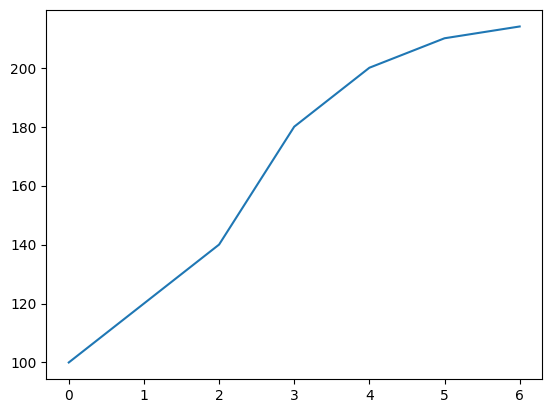

In [3]:
data = [100, 120, 140, 180, 200, 210, 214]
s = pd.Series(data, index=range(len(data)))

s.plot()

<Axes: >

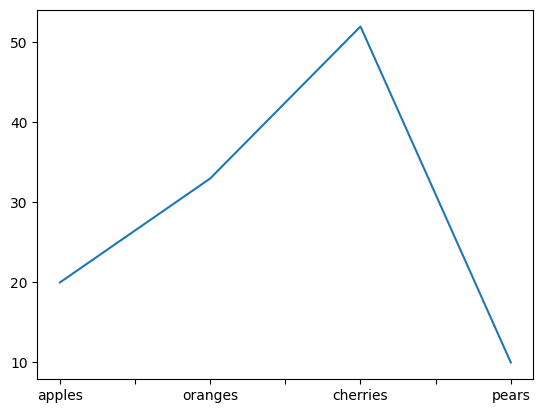

In [4]:
fruits = ['apples', 'oranges', 'cherries', 'pears']
quantities = [20, 33, 52, 10]
S = pd.Series(quantities, index=fruits)
S.plot()

<Axes: >

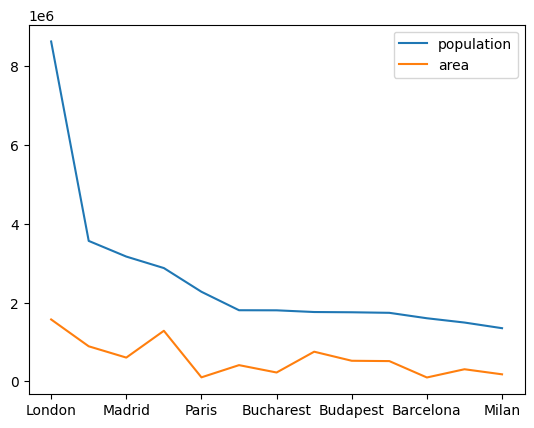

In [8]:
cities = {"name": ["London", "Berlin", "Madrid", "Rome", 
                   "Paris", "Vienna", "Bucharest", "Hamburg", 
                   "Budapest", "Warsaw", "Barcelona", 
                   "Munich", "Milan"],
          "population": [8615246, 3562166, 3165235, 2874038,
                         2273305, 1805681, 1803425, 1760433,
                         1754000, 1740119, 1602386, 1493900,
                         1350680],
          "area" : [1572, 891.85, 605.77, 1285, 
                    105.4, 414.6, 228, 755, 
                    525.2, 517, 101.9, 310.4, 
                    181.8]
}

city_frame = pd.DataFrame(cities, columns=["population", "area"], index=cities["name"])
city_frame['area'] *= 1000
city_frame.plot()

<Axes: >

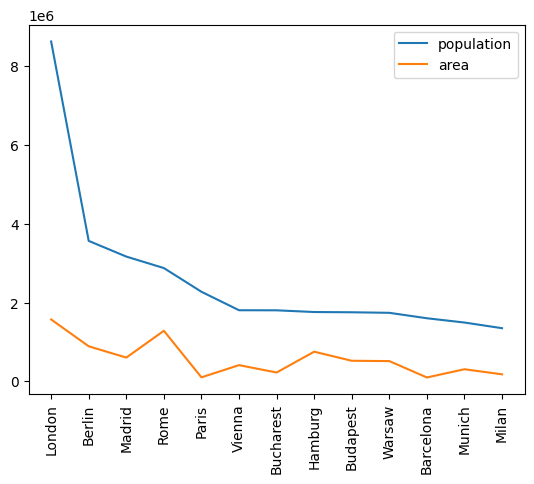

In [9]:
city_frame.plot(xticks=range(len(city_frame.index)),
                use_index=True, 
                rot=90)

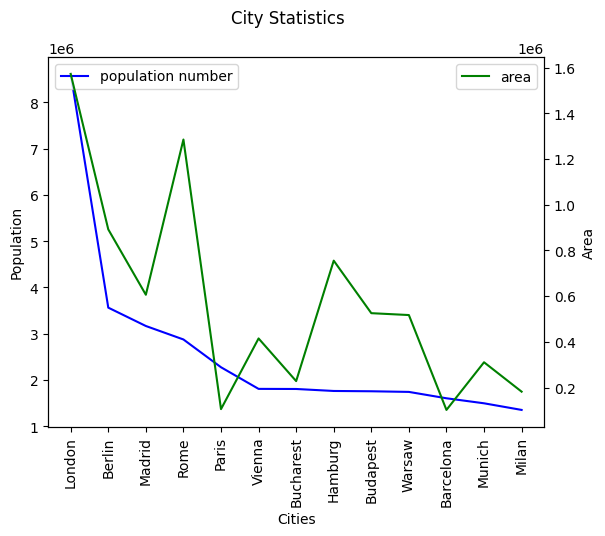

In [12]:
fig, ax = plt.subplots()
fig.suptitle("City Statistics")
ax.set_ylabel("Population")
ax.set_xlabel("Cities")

ax2 = ax.twinx()
ax2.set_ylabel("Area")

city_frame["population"].plot(ax=ax, 
                              style="b-",
                              xticks=range(len(city_frame.index)),
                              use_index=True, 
                              rot=90)

city_frame["area"].plot(ax=ax2, 
                        style="g-",
                        use_index=True, 
                        rot=90)

ax.legend(["population number"], loc=2)
ax2.legend(loc=1)

plt.show()

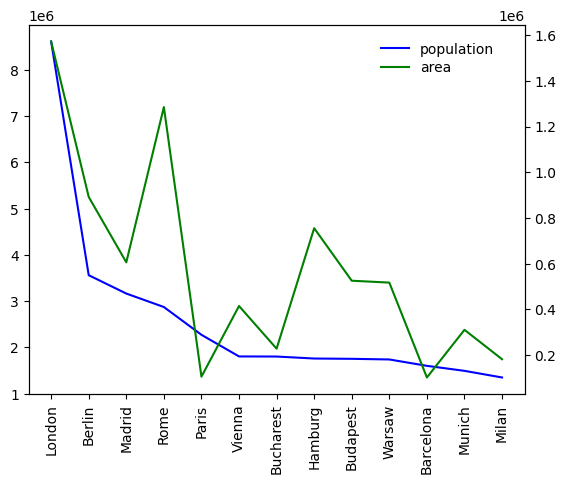

In [14]:
ax1= city_frame["population"].plot(style="b-",
                                   xticks=range(len(city_frame.index)),
                                   use_index=True, 
                                   rot=90)
ax2 = ax1.twinx()

city_frame["area"].plot(ax=ax2, style="g-", use_index=True, rot=90)

ax1.legend(loc = (.7,.9), frameon = False)
ax2.legend( loc = (.7, .85), frameon = False)

plt.show()

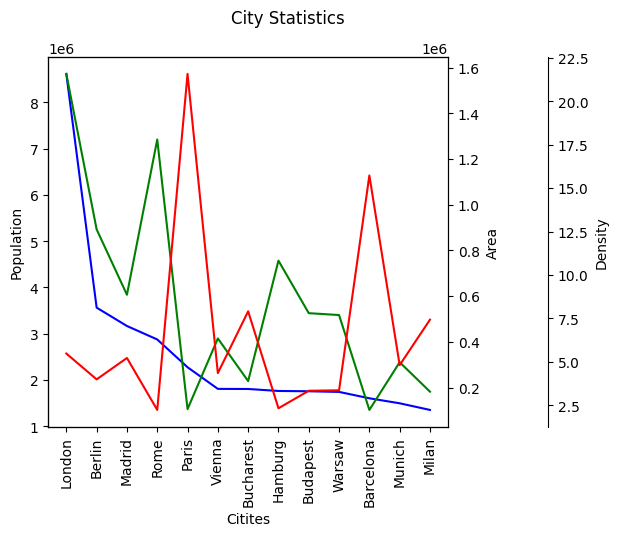

In [17]:
city_frame["density"] = city_frame["population"] / city_frame["area"]

fig, ax = plt.subplots()
fig.suptitle("City Statistics")
ax.set_ylabel("Population")
ax.set_xlabel("Citites")

ax_area, ax_density = ax.twinx(), ax.twinx() 
ax_area.set_ylabel("Area")
ax_density.set_ylabel("Density")

rspine = ax_density.spines['right']
rspine.set_position(('axes', 1.25))
ax_density.set_frame_on(True)
ax_density.patch.set_visible(False)
fig.subplots_adjust(right=0.75)

city_frame["population"].plot(ax=ax, 
                              style="b-",
                              xticks=range(len(city_frame.index)),
                              use_index=True, 
                              rot=90)

city_frame["area"].plot(ax=ax_area, 
                        style="g-",
                        use_index=True, 
                        rot=90)

city_frame["density"].plot(ax=ax_density, 
                           style="r-",
                           use_index=True, 
                           rot=90)

plt.show()

In [ ]:
headers = { 'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36' }

data = pd.read_csv( "https://python-course.eu/data1/python_course_monthly_history.txt",  quotechar='"', thousands=",", delimiter=r"\s+", storage_options=headers)

def unit_convert(x):
    value, unit = x
    if unit == "MB":
        value *= 1024
    elif unit == "GB":
        value *= 1024 ** 2
    return value

b_and_u= data[["Bandwidth", "Unit"]]
bandwidth = b_and_u.apply(unit_convert, axis=1)

del data["Unit"]
data["Bandwidth"] = bandwidth

month_year =  data[["Month", "Year"]]
month_year = month_year.apply(lambda x: x[0] + " " + str(x[1]), 
                              axis=1)
data["Month"] = month_year
del data["Year"]

data.set_index("Month", inplace=True)
del data["Bandwidth"]

data[["Unique visitors", "Number of visits"]].plot(use_index=True, rot=90, xticks=range(1, len(data.index),4))

In [ ]:
def strip_percentage_sign(x):
    return float(x.strip('%'))

data_path = "../data1/"
progs = pd.read_csv(data_path + "tiobe_programming_language_usage_nov2018.txt", 
                   quotechar='"',
                   thousands=",",
                   index_col=1,
                   converters={'Percentage':strip_percentage_sign},
                   delimiter=r"\s+")

del progs["Position"]

print(progs.head(6))

<Axes: >

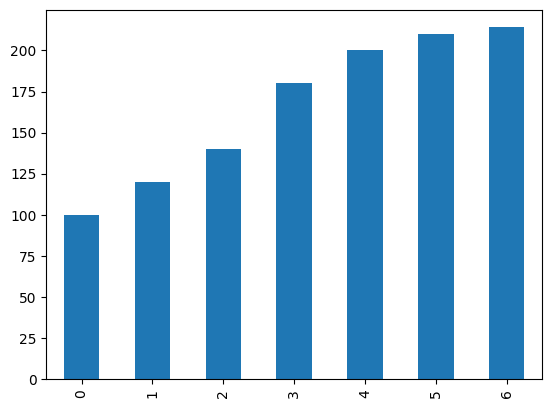

In [26]:
data = [100, 120, 140, 180, 200, 210, 214]
s = pd.Series(data, index=range(len(data)))

s.plot(kind="bar")

<Axes: >

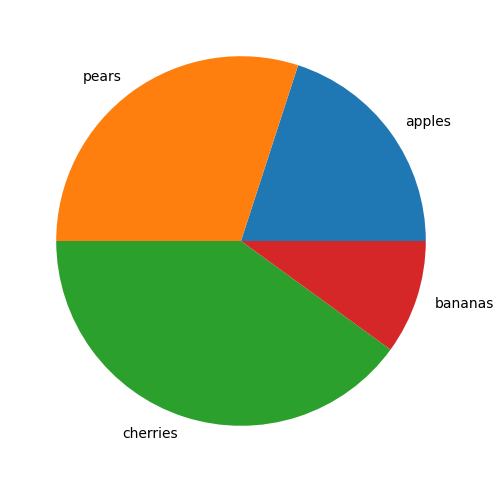

In [28]:
fruits = ['apples', 'pears', 'cherries', 'bananas']
series = pd.Series([20, 30, 40, 10], 
                   index=fruits, 
                   name='series')

series.plot.pie(figsize=(6, 6))

<Axes: >

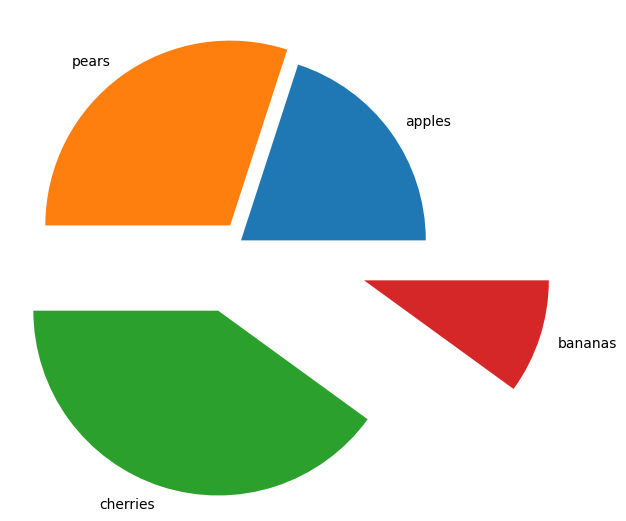

In [30]:
fruits = ['apples', 'pears', 'cherries', 'bananas']

series = pd.Series([20, 30, 40, 10],  index=fruits, name='series')
explode = [0, 0.10, 0.40, 0.7]
series.plot.pie(figsize=(6, 6), explode=explode)

### 13. Python Date and Time

In [2]:
from datetime import date

x = date(1993, 12, 14)
print(x)

1993-12-14


In [3]:
print(date.min)
print(date.max)

0001-01-01
9999-12-31


In [8]:
x = date(2026, 3, 10)
x.toordinal()

date.fromordinal( x.toordinal() )

datetime.date(2026, 3, 10)

In [9]:
x.weekday()

1

In [10]:
date.today()

datetime.date(2026, 3, 10)

In [11]:
print(x.day)
print(x.month)
print(x.year)

10
3
2026


In [12]:
from datetime import time

t = time(15, 6, 23)
print(t)

15:06:23


In [13]:
print(time.min)
print(time.max)

00:00:00
23:59:59.999999


In [14]:
t.hour, t.minute, t.second

(15, 6, 23)

In [15]:
t = t.replace(hour=11, minute=59)
t

datetime.time(11, 59, 23)

In [16]:
x.ctime()

'Tue Mar 10 00:00:00 2026'

In [19]:
from datetime import datetime
t = datetime(2017, 4, 19, 16, 31, 0)
t

datetime.datetime(2017, 4, 19, 16, 31)

In [22]:
t.tzinfo

In [ ]:
from datetime import datetime
import pytz
t = datetime.now(pytz.utc)

In [24]:
from datetime import datetime, timedelta as delta
ndays = 15
start = datetime(1991, 4, 30)
dates = [start - delta(days=x) for x in range(0, ndays)]
dates

[datetime.datetime(1991, 4, 30, 0, 0),
 datetime.datetime(1991, 4, 29, 0, 0),
 datetime.datetime(1991, 4, 28, 0, 0),
 datetime.datetime(1991, 4, 27, 0, 0),
 datetime.datetime(1991, 4, 26, 0, 0),
 datetime.datetime(1991, 4, 25, 0, 0),
 datetime.datetime(1991, 4, 24, 0, 0),
 datetime.datetime(1991, 4, 23, 0, 0),
 datetime.datetime(1991, 4, 22, 0, 0),
 datetime.datetime(1991, 4, 21, 0, 0),
 datetime.datetime(1991, 4, 20, 0, 0),
 datetime.datetime(1991, 4, 19, 0, 0),
 datetime.datetime(1991, 4, 18, 0, 0),
 datetime.datetime(1991, 4, 17, 0, 0),
 datetime.datetime(1991, 4, 16, 0, 0)]

In [40]:
from datetime import datetime

delta = datetime(1993, 12, 14) - datetime(1991, 4, 30)
delta, type(delta)

(datetime.timedelta(days=959), datetime.timedelta)

In [44]:
t1 = datetime(2017, 1, 31, 14, 17)
t2 = datetime(2015, 12, 15, 16, 59)
delta = t1 - t2
delta.days, delta.seconds, delta.total_seconds()

(412, 76680, 35673480.0)

In [48]:
from datetime import datetime, timedelta
d1 = datetime(1991, 4, 30)
d2 = d1 + timedelta(10)
print(d2)
print(d2 - d1)

d3 = d1 - timedelta(100)
print(d3)
d4 = d1 - 2 * timedelta(50)
print(d4)

1991-05-10 00:00:00
10 days, 0:00:00
1991-01-20 00:00:00
1991-01-20 00:00:00


In [50]:
from datetime import datetime, timedelta
d1 = datetime(1991, 4, 30)
d2 = d1 + timedelta(10,100)
print(d2)
print(d2 - d1)

1991-05-10 00:01:40
10 days, 0:01:40


In [52]:
print(d1.strftime('%Y-%m-%d'))
print("weekday: " + d1.strftime('%a'))
print("weekday as a full name: " + d1.strftime('%A'))
print("weekday as a decimal number: " + d1.strftime('%w'))

1991-04-30
weekday: Tue
weekday as a full name: Tuesday
weekday as a decimal number: 2


In [53]:
print(d1.strftime('%d'))
print(d1.strftime('%b'))
print(d1.strftime('%B'))
print(d1.strftime('%m'))

30
Apr
April
04


In [54]:
from datetime import datetime
t = datetime.strptime("30 Nov 00", "%d %b %y")
print(t)

2000-11-30 00:00:00


In [56]:
from dateutil.parser import parse
parse('2011-01-03')

datetime.datetime(2011, 1, 3, 0, 0)

In [62]:
parse('Wed Apr 12 20:29:53 CEST 2017')

datetime.datetime(2017, 4, 12, 20, 29, 53)

### 14. Time Series in Pandas and Python

In [24]:
import numpy as np
import pandas as pd

from datetime import datetime, timedelta as delta
ndays = 10
start = datetime(2017, 3, 31)
dates = [start - delta(days=x) for x in range(0, ndays)]

values = [25, 50, 15, 67, 70, 9, 28, 30, 32, 12]

ts = pd.Series(values, index=dates)
ts

2017-03-31    25
2017-03-30    50
2017-03-29    15
2017-03-28    67
2017-03-27    70
2017-03-26     9
2017-03-25    28
2017-03-24    30
2017-03-23    32
2017-03-22    12
dtype: int64

<Axes: >

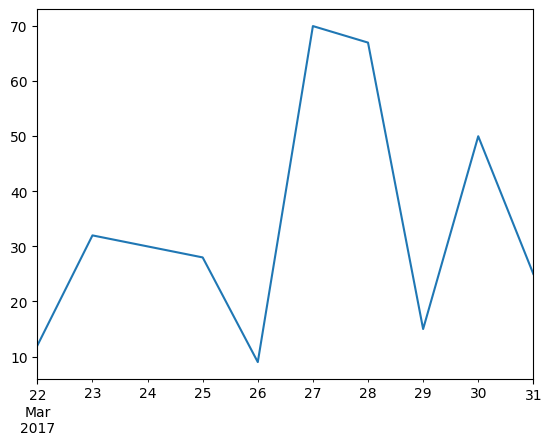

In [25]:
ts.plot()

In [26]:
ndays = 10

start = datetime(2017, 3, 31)
dates = [start - delta(days=x) for x in range(0, ndays)]

start2 = datetime(2017, 3, 26)
dates2 = [start2 - delta(days=x) for x in range(0, ndays)]

values = [25, 50, 15, 67, 70, 9, 28, 30, 32, 12]
values2 = [32, 54, 18, 61, 72, 19, 21, 33, 29, 17]

ts = pd.Series(values, index=dates)
ts2 = pd.Series(values2, index=dates2)

ts + ts2

2017-03-17     NaN
2017-03-18     NaN
2017-03-19     NaN
2017-03-20     NaN
2017-03-21     NaN
2017-03-22    84.0
2017-03-23    93.0
2017-03-24    48.0
2017-03-25    82.0
2017-03-26    41.0
2017-03-27     NaN
2017-03-28     NaN
2017-03-29     NaN
2017-03-30     NaN
2017-03-31     NaN
Freq: D, dtype: float64

In [27]:
index = pd.date_range('12/24/1970', '01/03/1971')
print(index)

index = pd.date_range(start='12/24/1970', periods=4)
print(index)

index = pd.date_range('2017-04-07', '2017-04-13', freq="B")
print(index)

DatetimeIndex(['1970-12-24', '1970-12-25', '1970-12-26', '1970-12-27',
               '1970-12-28', '1970-12-29', '1970-12-30', '1970-12-31',
               '1971-01-01', '1971-01-02', '1971-01-03'],
              dtype='datetime64[us]', freq='D')
DatetimeIndex(['1970-12-24', '1970-12-25', '1970-12-26', '1970-12-27'], dtype='datetime64[us]', freq='D')
DatetimeIndex(['2017-04-07', '2017-04-10', '2017-04-11', '2017-04-12',
               '2017-04-13'],
              dtype='datetime64[us]', freq='B')


In [28]:
index = pd.date_range('2016-02-25', '2016-07-02', freq="ME")
index

DatetimeIndex(['2016-02-29', '2016-03-31', '2016-04-30', '2016-05-31',
               '2016-06-30'],
              dtype='datetime64[us]', freq='ME')

### 39. Expenses and income example with Pandas and Python

In [29]:
exp_inc = pd.read_csv('data.csv', sep=";")
exp_inc

,Date,Description,Category,Out,In
0,2020-06-02,Salary Frank,Income,0.00,4896.44
1,2020-06-03,supermarket,food and beverages,132.40,0.00
2,2020-06-04,Salary Laura,Income,0.00,4910.14
3,2929-06-04,"GreenEnergy Corp., (electricity)",utility,87.34,0.00
4,2020-06-09,water and sewage,utility,60.56,0.00
5,2020-06-10,"Fitness studio, Jane",health and sports,19.00,0.00
6,2020-06-11,payment to bank,monthly redemption payment,1287.43,0.00
7,2020-06-12,LeGourmet Restaurant,restaurants and hotels,145.00,0.00
8,2020-06-13,supermarket,food and beverages,197.42,0.00
9,2020-06-13,Pizzeria da Pulcinella,restaurants and hotels,60.00,0.00


In [30]:
exp_inc[['Out', 'In']].sum()

Out     5097.44
In     19613.16
dtype: float64

In [31]:
category_sums = exp_inc.groupby("Category").sum()
category_sums

,Date,Description,Out,In
Category,,,,
Income,2020-06-022020-06-042020-07-022020-07-05,Salary FrankSalary LauraSalary FrankSalary Laura,0.00,19613.16
education and culture,2020-06-272020-07-23,theatre ticketsCinema,144.00,0.00
food and beverages,2020-06-032020-06-132020-06-262020-07-032020-0...,supermarketsupermarketsupermarketsupermarketsu...,1174.61,0.00
health and sports,2020-06-102020-07-082020-07-10,"Fitness studio, JaneGolf Club, yearly paymentF...",650.18,0.00
insurances and taxes,2020-07-09,house insurance,167.89,0.00
monthly redemption payment,2020-06-112020-07-11,payment to bankpayment to bank,2574.86,0.00
restaurants and hotels,2020-06-122020-06-132020-07-13,LeGourmet RestaurantPizzeria da PulcinellaPizz...,238.00,0.00
utility,2929-06-042020-06-09,"GreenEnergy Corp., (electricity)water and sewage",147.90,0.00


(array([0, 1, 2, 3, 4, 5, 6, 7]),
 [Text(0, 0, 'Income'),
  Text(1, 0, 'education and culture'),
  Text(2, 0, 'food and beverages'),
  Text(3, 0, 'health and sports'),
  Text(4, 0, 'insurances and taxes'),
  Text(5, 0, 'monthly redemption payment'),
  Text(6, 0, 'restaurants and hotels'),
  Text(7, 0, 'utility')])

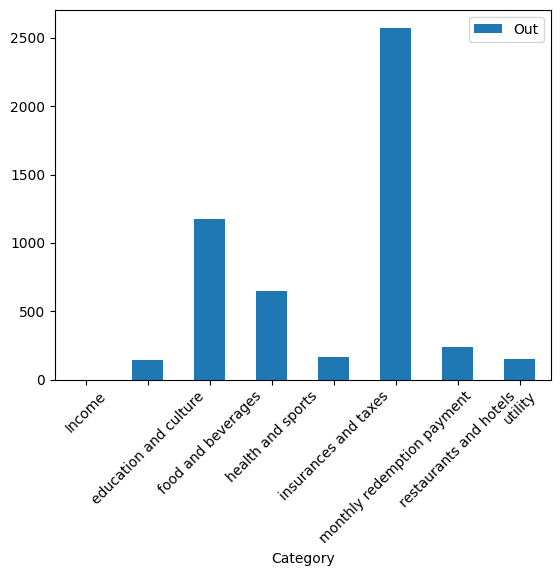

In [38]:
import matplotlib.pyplot as plt

category_sums.plot.bar(y="Out")
plt.xticks(rotation=45)

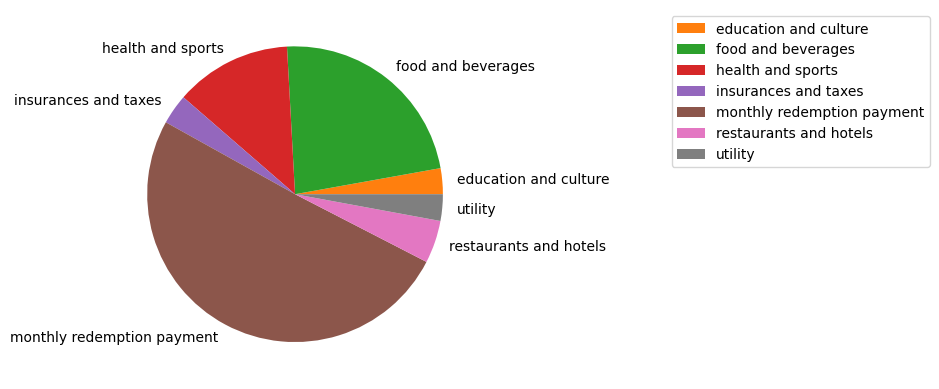

In [41]:
ax = category_sums.plot.pie(y="Out")
ax.legend(loc="upper left", bbox_to_anchor=(1.5, 1))

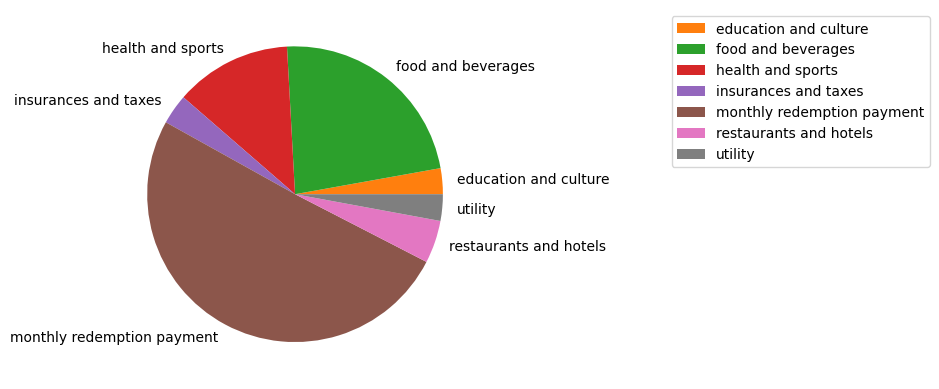

In [42]:
ax = category_sums["Out"].plot.pie()
ax.legend(loc="upper left", bbox_to_anchor=(1.5, 1))

### 15. Net Income Method Example with Numpy, Matplotlib and Scipy

In [3]:
import pandas as pd

headers = { 'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36' }

with pd.read_excel("https://python-course.eu/data1/net_income_method_2020.xlsx", storage_options=headers) as xl:
    accounts2descr = xl.parse("account numbers", index_col=0)
    journal = xl.parse("journal", index_col=0, )
    
journal.index = pd.to_datetime(journal.index)
journal.index

TypeError: 'pandas.DataFrame' object does not support the context manager protocol (missed __exit__ method)

### 16.Estimation of Corona cases with Python and Pandas 

            cases  active  deaths
dates                            
2020-02-17     16       9       0
2020-02-18     16       7       0
2020-02-19     16       7       0
2020-02-20     16       3       0
2020-02-21     16       2       0


<Axes: xlabel='dates'>

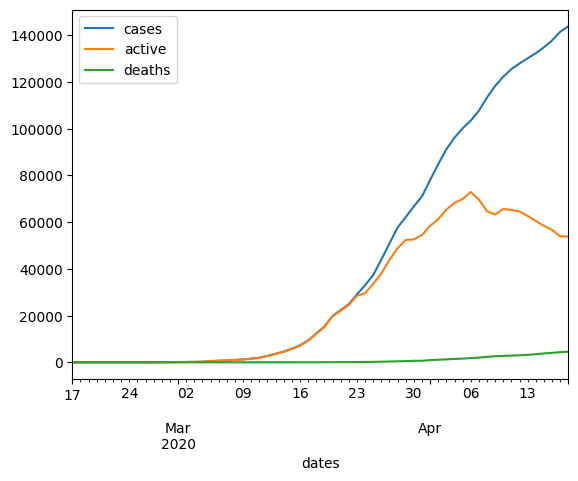

In [4]:
xf = pd.ExcelFile("coronacases.xlsx")
df = xf.parse("Sheet1", skiprows=2, index_col=0, names=["dates", "cases", "active", "deaths"])
print(df.head())
df[["cases", "active", "deaths"]].plot()

            death_ratio  healed_ratio
dates                                
2020-02-17     0.000000    100.000000
2020-02-18     0.000000    100.000000
2020-02-19     0.000000    100.000000
2020-02-20     0.000000    100.000000
2020-02-21     0.000000    100.000000
...                 ...           ...
2020-04-14     4.874817     95.125183
2020-04-15     4.978797     95.021203
2020-04-16     4.999260     95.000740
2020-04-17     4.975648     95.024352
2020-04-18     5.045698     94.954302

[62 rows x 2 columns]


<Axes: xlabel='dates'>

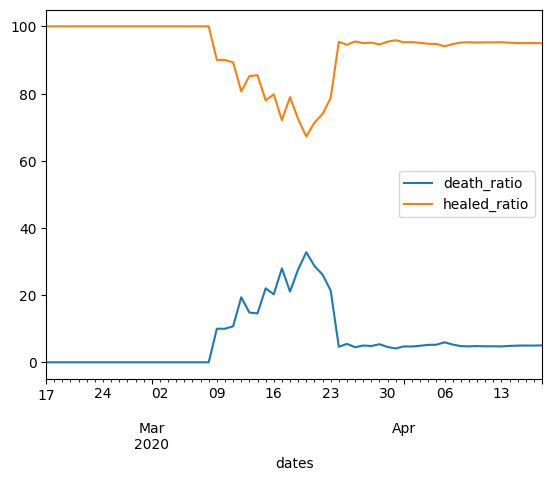

In [5]:
discharged = df["cases"] - df["active"]

if "healed" in df.columns:
    df.drop("healed", axis=1, inplace=True)
if "healed" not in df.columns:
    df.insert(loc=len(df.columns),
              column="healed",
              value=(discharged -df["deaths"]))

healed_ratio = df["healed"] * 100 / discharged
death_ratio = df["deaths"] * 100 / discharged

outcome = {"death_ratio": death_ratio, "healed_ratio": healed_ratio}
outcome_df = pd.DataFrame(outcome)
print(outcome_df)
outcome_df.plot()

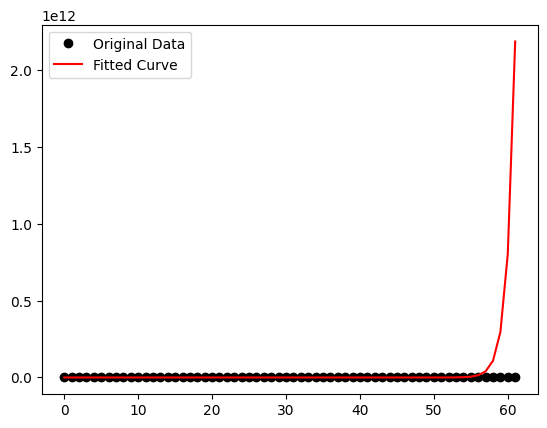

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def growth_func(x, a, b, c):
  return a * np.exp(b * x) + c
  
Y = df.cases.values
X = np.arange(0, len(Y))
popt, pcov = curve_fit(growth_func, X, Y)

def growth(x):
    return growth_func(x, *popt)

plt.figure()
plt.plot(X, Y, 'ko', label="Original Data")
plt.plot(X, growth(X), 'r-', label="Fitted Curve")
plt.legend()
plt.show()

### 16. inear Combinations in Python

In [1]:
import numpy as np
x = np.array([[0, 0, 1],
              [0, 1, 0],
              [1, 0, 0]])
y = ([3.65, 1.55, 3.42])
scalars = np.linalg.solve(x, y)
scalars

array([3.42, 1.55, 3.65])

In [2]:
import numpy as np
x = np.array([[0, 1, 1],
              [1, 1, 0],
              [1, 0, 1]])
y = ([3.65, 1.55, 3.42])
scalars = np.linalg.solve(x, y)
scalars

array([0.66, 0.89, 2.76])